# Evaluation — Pima Diabetes

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import time
import numpy as np
import matplotlib.pyplot as plt

from pipeline import (
    load_diabetes, train_test_split, DIABETES_MUTABLE as MUTABLE_COLS,
    train, compute_hessian, predict, score,
    fit_mice, calibrate_rho,
    beam_search,
    nominal_validity, model_retrain_validity, train_bootstrap_models,
    awp_validity, lof_plausibility, fit_lof, l2_proximity,
    print_recourse_summary,
)

%matplotlib inline

## Setup

In [2]:
X, Xi, y, Phi, feature_names, col_means, col_stds = load_diabetes()
train_idx, test_idx = train_test_split(len(y))

X_train,  Xi_train  = X[train_idx],  Xi[train_idx]
Phi_train, y_train  = Phi[train_idx], y[train_idx]

theta_hat, _   = train(Phi_train, y_train)
hessian_matrix = compute_hessian(Phi_train, theta_hat)
mice_imputer   = fit_mice(X_train, Xi_train)

train_acc = (predict(Phi[train_idx], theta_hat) == y[train_idx]).mean()
test_acc  = (predict(Phi[test_idx],  theta_hat) == y[test_idx]).mean()
print(f'train acc: {train_acc:.3f}  test acc: {test_acc:.3f}')

n=768  d=8  not_diabetic=500  diabetic=268
  Glucose                          5 missing (0.7%)
  BloodPressure                   35 missing (4.6%)
  SkinThickness                  227 missing (29.6%)
  Insulin                        374 missing (48.7%)
  BMI                             11 missing (1.4%)
train acc: 0.774  test acc: 0.765


In [3]:
# precompute shared eval objects
print('precomputing bootstrap models and LOF...', end=' ', flush=True)
t_pre = time.time()
bootstrap_models = train_bootstrap_models(X_train, Xi_train, y_train, n_models=50)
lof_model        = fit_lof(X_train, Xi_train, mice_imputer)
print(f'done ({time.time() - t_pre:.1f}s)')

precomputing bootstrap models and LOF... done (0.4s)


In [4]:
# hyperparameters
EPSILON      = 0.001
RHO_COVERAGE = 0.90
KAPPA_VAL    = 0.5
DELTA_MAX    = 2.0
BEAM_WIDTH   = 3
K_MAX        = 3
K_MICE       = 100

kappa  = np.ones(len(X[0])) * KAPPA_VAL
J_edit = MUTABLE_COLS

denied_all = [
    i for i in test_idx
    if predict(Phi[[i]], theta_hat)[0] == -1 and Xi[i].sum() > 0
]
print(f'denied test individuals with missing features: {len(denied_all)}')

denied test individuals with missing features: 31


## Score distribution

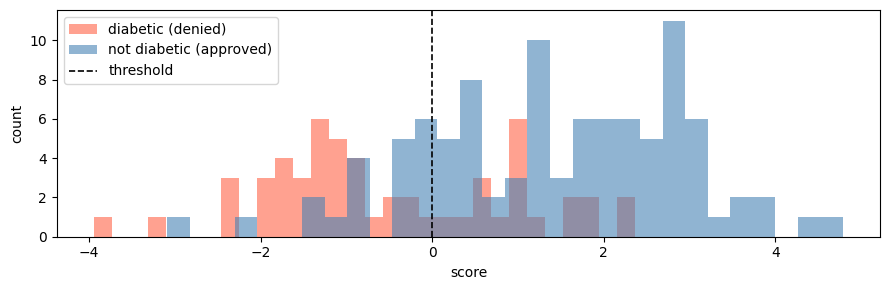

In [5]:
test_scores = score(Phi[test_idx], theta_hat)
y_test = y[test_idx]

fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(test_scores[y_test == -1], bins=30, alpha=0.6, color='tomato',    label='diabetic (denied)')
ax.hist(test_scores[y_test ==  1], bins=30, alpha=0.6, color='steelblue', label='not diabetic (approved)')
ax.axvline(0, color='black', linestyle='--', linewidth=1.2, label='threshold')
ax.set_xlabel("score")
ax.set_ylabel("count")
ax.legend()
plt.tight_layout()
plt.show()

## Single-person walkthrough

Pick one denied person, run recourse, then evaluate each metric individually (Units 1-6 from the writeup).

In [6]:
# pick a denied person with missing features
person_idx = denied_all[0]
x0   = X[person_idx]
xi0  = Xi[person_idx]
raw_score = score(Phi[[person_idx]], theta_hat)[0]

print(f"person {person_idx}  |  score: {raw_score:.4f}  (needs >= 0 for approved)")
print(f"missing: {[feature_names[j] for j in np.where(xi0 == 1)[0]] or 'none'}")
print()
for j, name in enumerate(feature_names):
    status = ' [missing]' if xi0[j] == 1 else ''
    print(f"  {name:<30} {x0[j]:>7.3f}{status}")

person 336  |  score: -0.3696  (needs >= 0 for approved)
missing: ['BloodPressure', 'SkinThickness', 'Insulin']

  Pregnancies                     -1.142
  Glucose                         -0.154
  BloodPressure                    0.000 [missing]
  SkinThickness                    0.000 [missing]
  Insulin                          0.000 [missing]
  BMI                              0.194
  DiabetesPedigreeFunction         1.390
  Age                              0.915


In [7]:
# run recourse (beam search)
import matplotlib.patches as mpatches

best_r, best_delta, best_cost, history, best_mu, best_Sigma, best_draws, best_rho_opt = beam_search(
    x0, xi0, theta_hat, hessian_matrix, mice_imputer,
    epsilon=EPSILON, rho_coverage=RHO_COVERAGE, kappa=kappa, J_edit=J_edit,
    tau=0.0, beam_width=BEAM_WIDTH, K_max=K_MAX, K_mice=K_MICE,
    x_min=x0 - DELTA_MAX, x_max=x0 + DELTA_MAX,
    verbose=True,
)

if best_r is not None:
    print(f"\ntotal cost: {best_cost:.4f}")
    print(f"reveal    : {[feature_names[j] for j in np.where(best_r == 1)[0]] or 'nothing'}")
    print()
    print(f"{'feature':<30} {'from':>8} {'to':>8} {'change':>8}")
    print('-' * 56)
    for j in range(len(x0)):
        if abs(best_delta[j]) > 1e-4:
            old, new = x0[j], x0[j] + best_delta[j]
            print(f"{feature_names[j]:<30} {old:>8.3f} {new:>8.3f} {new-old:>+8.3f}")
else:
    print("no feasible recourse found")


step 0: 1 candidate(s)
  r=[0, 0, 0, 0, 0, 0, 0, 0]  cost=1.2894

step 1: 3 candidate(s)
  r=[0, 0, 1, 0, 0, 0, 0, 0]  cost=0.9627
  r=[0, 0, 0, 1, 0, 0, 0, 0]  cost=1.9137
  r=[0, 0, 0, 0, 1, 0, 0, 0]  cost=1.2657

step 2: 3 candidate(s)
  r=[0, 0, 1, 1, 0, 0, 0, 0]  cost=1.4752
  r=[0, 0, 1, 0, 1, 0, 0, 0]  cost=1.0000
  r=[0, 0, 0, 1, 1, 0, 0, 0]  cost=1.7536

step 3: 1 candidate(s)
  r=[0, 0, 1, 1, 1, 0, 0, 0]  cost=1.5000

total cost: 0.9627
reveal    : ['BloodPressure']

feature                            from       to   change
--------------------------------------------------------
Glucose                          -0.154   -0.542   -0.388
BloodPressure                     0.000    0.059   +0.059
BMI                               0.194   -0.051   -0.245


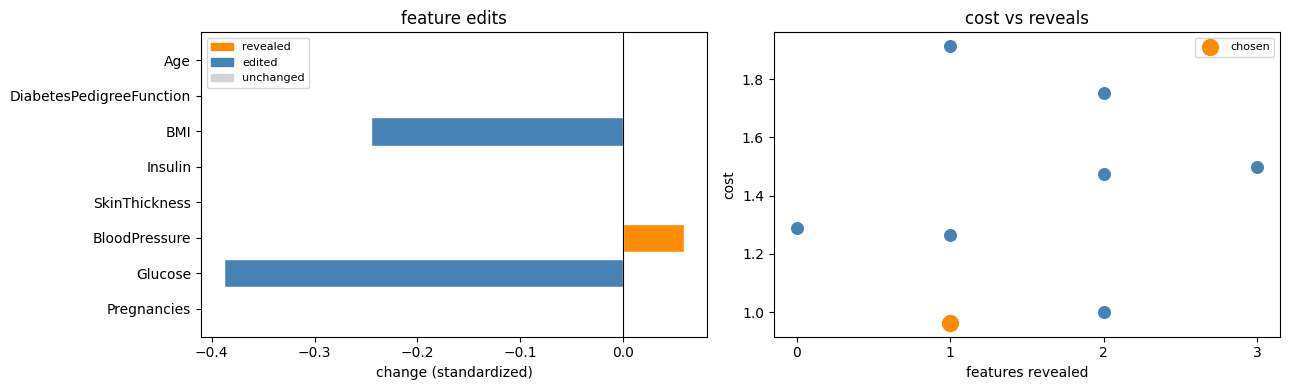

In [8]:
# feature edits visualization
if best_r is not None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    ax = axes[0]
    colors = ['darkorange' if best_r[j] == 1
              else 'steelblue' if abs(best_delta[j]) > 1e-4
              else 'lightgrey'
              for j in range(len(feature_names))]
    ax.barh(feature_names, best_delta, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel("change (standardized)")
    ax.set_title("feature edits")
    ax.legend(handles=[
        mpatches.Patch(color='darkorange', label='revealed'),
        mpatches.Patch(color='steelblue',  label='edited'),
        mpatches.Patch(color='lightgrey',  label='unchanged'),
    ], fontsize=8)

    ax2 = axes[1]
    feasible_h = [h for h in history if h['feasible']]
    if feasible_h:
        n_reveals = [int(h['r'].sum()) for h in feasible_h]
        costs     = [h['cost'] for h in feasible_h]
        ax2.scatter(n_reveals, costs, s=70, color='steelblue', zorder=3)
        ax2.scatter([int(best_r.sum())], [best_cost], s=130, color='darkorange',
                    zorder=4, label='chosen')
        ax2.set_xlabel("features revealed")
        ax2.set_ylabel("cost")
        ax2.set_title("cost vs reveals")
        ax2.set_xticks(sorted(set(n_reveals)))
        ax2.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

### Unit 1 — Nominal Validity

Does the recommended action flip the model's decision? Basic correctness check.

In [9]:
nom = nominal_validity(theta_hat, x0, best_delta, xi0, best_r, best_mu)
print(f"nominal validity: {nom}")

nominal validity: True


### Unit 2 — Model Retrain Validity

Does the recourse hold across 50 bootstrap-retrained models?

In [10]:
rr = model_retrain_validity(x0, best_delta, xi0, best_r, best_mu, bootstrap_models)
print(f"model retrain validity: {rr:.3f}  (50 bootstrap retrains)")

model retrain validity: 0.980  (50 bootstrap retrains)


### Unit 3 — AWP Validity (Sanity Check)

Does the Proposition 2 lower bound hold at the optimization-time parameters?

In [11]:
awp_sanity, lb_sanity = awp_validity(
    theta_hat, hessian_matrix,
    x0, best_delta, xi0, best_r, best_mu, best_Sigma,
    epsilon_eval=EPSILON, rho_eval=best_rho_opt,
)
print(f"awp sanity  eps={EPSILON}  rho={best_rho_opt:.2f}  : {awp_sanity}  lb={lb_sanity:.4f}")

awp sanity  eps=0.001  rho=2.11  : True  lb=0.0001


### Unit 4 — LOF Plausibility

Is the post-action person realistic? Score close to 1.0 = in-distribution.

In [12]:
lof = lof_plausibility(x0, best_delta, xi0, best_r, best_mu, lof_model)
print(f"lof plausibility: {lof:.4f}  (1.0 = perfectly in-distribution)")

lof plausibility: 1.2157  (1.0 = perfectly in-distribution)


### Unit 5 — l2 Proximity

How far did we move the person in feature space? Over observed features only.

In [13]:
l2 = l2_proximity(x0, best_delta, xi0, best_r, best_mu)
print(f"l2 proximity: {l2:.4f}")

l2 proximity: 0.4627


### Unit 6 — Per-Person Qualitative Output

Feature-level table in original units.

In [14]:
metrics = {
    'total_cost': best_cost,
    'nominal':    nom,
    'retrain':    rr,
    'awp_sanity': awp_sanity, 'lb_sanity': lb_sanity,
    'lof':        lof,
}
print_recourse_summary(
    x0, xi0, best_r, best_delta, col_means, col_stds, feature_names,
    kappa=kappa, metrics=metrics,
)

--------------------------------------------------------------------------------
Feature                       Original  Miss  Reveal  Post-Action      Change
--------------------------------------------------------------------------------
Pregnancies                       0.00    no       -         0.00           -
Glucose                         117.00    no       -       105.16      -11.84
BloodPressure                      ---   yes     yes        73.14    revealed
SkinThickness                      ---   yes       -          ---           -
Insulin                            ---   yes       -          ---           -
BMI                              33.80    no       -        32.10       -1.70
DiabetesPedigreeFunction          0.93    no       -         0.93           -
Age                              44.00    no       -        44.00           -
--------------------------------------------------------------------------------
  cost             : total=0.9627  reveal=0.5000  edit=

### Sensitivity to epsilon

epsilon=0.0001  cost=0.5891
epsilon=0.0005  cost=0.8095
epsilon=0.0010  cost=0.9777
epsilon=0.0050  cost=1.5140
epsilon=0.0100  cost=1.8640
epsilon=0.0500  cost=3.6127


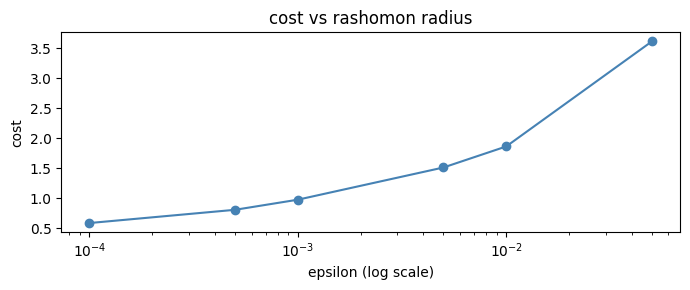

In [15]:
epsilons = [1e-4, 5e-4, 0.001, 0.005, 0.01, 0.05]
costs    = []

for eps in epsilons:
    _, _, cost, _, _, _, _, _ = beam_search(
        x0, xi0, theta_hat, hessian_matrix, mice_imputer,
        epsilon=eps, rho_coverage=RHO_COVERAGE, kappa=kappa, J_edit=J_edit,
        tau=0.0, beam_width=3, K_max=3, K_mice=50,
        x_min=x0 - DELTA_MAX, x_max=x0 + DELTA_MAX,
        verbose=False,
    )
    costs.append(cost)
    status = f"cost={cost:.4f}" if cost < np.inf else "infeasible"
    print(f"epsilon={eps:.4f}  {status}")

fig, ax = plt.subplots(figsize=(7, 3))
feasible_eps   = [e for e, c in zip(epsilons, costs) if c < np.inf]
feasible_costs = [c for c in costs if c < np.inf]
ax.plot(feasible_eps, feasible_costs, 'o-', color='steelblue')
ax.set_xscale('log')
ax.set_xlabel("epsilon (log scale)")
ax.set_ylabel("cost")
ax.set_title("cost vs rashomon radius")
plt.tight_layout()
plt.show()

## Run 4 conditions

In [16]:
conditions = [
    ('ours',      EPSILON, K_MAX, None),
    ('baseline',  0.0,     K_MAX, None),
    ('no-robust', 0.0,     K_MAX, 0.0),
    ('no-reveal', EPSILON, 0,     None),
]

all_results = {}

for label, eps, k_max_c, rho_override in conditions:
    print('=' * 70)
    print(f'{label.upper()}  (epsilon={eps}, k_max={k_max_c}'
          f'{", rho_override=" + str(rho_override) if rho_override is not None else ""})')
    print('=' * 70)

    results = []
    for idx in denied_all:
        x0, xi0 = X[idx], Xi[idx]

        t0 = time.time()
        r, delta, cost, _, mu, Sigma, _, rho_opt = beam_search(
            x0, xi0, theta_hat, hessian_matrix, mice_imputer,
            epsilon=eps, rho_coverage=RHO_COVERAGE, kappa=kappa, J_edit=J_edit,
            tau=0.0, beam_width=BEAM_WIDTH, K_max=k_max_c, K_mice=K_MICE,
            x_min=x0 - DELTA_MAX, x_max=x0 + DELTA_MAX,
            verbose=False, rho_override=rho_override,
        )
        elapsed = time.time() - t0

        if r is None:
            results.append({'idx': idx, 'feasible': False, 'time': elapsed})
            print(f'  [{label}] person {idx}: infeasible')
            continue

        nom = nominal_validity(theta_hat, x0, delta, xi0, r, mu)
        rr  = model_retrain_validity(x0, delta, xi0, r, mu, bootstrap_models)
        awp, lb = awp_validity(
            theta_hat, hessian_matrix, x0, delta, xi0, r, mu, Sigma,
            epsilon_eval=EPSILON, rho_eval=rho_opt,
        )
        lof = lof_plausibility(x0, delta, xi0, r, mu, lof_model)
        l2  = l2_proximity(x0, delta, xi0, r, mu)

        results.append({
            'idx': idx, 'feasible': True, 'cost': cost,
            'nom': nom, 'rr': rr,
            'awp': awp, 'lb': lb,
            'lof': lof, 'l2': l2, 'time': elapsed,
        })
        print(f'  [{label}] person {idx:5d}  cost={cost:.3f}  '
              f'nom={nom}  rr={rr:.2f}  '
              f'awp={awp}(rho={rho_opt:.2f})  '
              f'lof={lof:.3f}  l2={l2:.3f}')

    all_results[label] = results
    print()

OURS  (epsilon=0.001, k_max=3)
  [ours] person   336  cost=0.963  nom=True  rr=0.98  awp=True(rho=2.11)  lof=1.216  l2=0.463
  [ours] person   148  cost=1.613  nom=True  rr=0.94  awp=True(rho=1.59)  lof=1.050  l2=1.113
  [ours] person   212  cost=2.161  nom=True  rr=0.86  awp=True(rho=0.00)  lof=1.058  l2=1.661
  [ours] person   604  cost=1.913  nom=True  rr=1.00  awp=True(rho=1.63)  lof=1.045  l2=0.913
  [ours] person    86  cost=0.705  nom=True  rr=0.88  awp=True(rho=0.00)  lof=1.327  l2=0.205
  [ours] person   209  cost=2.047  nom=True  rr=0.92  awp=True(rho=0.00)  lof=0.993  l2=1.547
  [ours] person   363  cost=2.156  nom=True  rr=0.98  awp=True(rho=1.59)  lof=1.102  l2=1.656
  [ours] person   300  cost=1.764  nom=True  rr=1.00  awp=True(rho=1.63)  lof=1.087  l2=0.764
  [ours] person    67  cost=1.068  nom=True  rr=0.96  awp=True(rho=1.59)  lof=1.358  l2=0.568
  [ours] person 579: infeasible
  [ours] person    78  cost=1.271  nom=True  rr=0.98  awp=True(rho=1.63)  lof=1.015  l2=0.2

## Summary

In [17]:
print('=' * 70)
print('SUMMARY')
print('=' * 70)

for label, _, _, _ in conditions:
    feas      = [r for r in all_results[label] if r['feasible']]
    n         = len(all_results[label])
    nf        = len(feas)
    time_vals = [r['time'] for r in all_results[label]]
    if nf == 0:
        print(f'{label:12s}  feasible=0/{n}  '
              f'time={np.mean(time_vals):.1f}s/person')
        continue
    cost_vals = [r['cost'] for r in feas]
    nom_vals  = [r['nom']  for r in feas]
    rr_vals   = [r['rr']   for r in feas]
    awp_vals  = [r['awp']  for r in feas]
    lof_vals  = [r['lof']  for r in feas]
    l2_vals   = [r['l2']   for r in feas]
    print(
        f'{label:12s}  '
        f'feasible={nf}/{n}  '
        f'cost={np.mean(cost_vals):.3f} (min={np.min(cost_vals):.3f})  '
        f'nominal={np.mean(nom_vals):.3f}  '
        f'retrain={np.mean(rr_vals):.3f} (min={np.min(rr_vals):.3f})  '
        f'awp={np.mean(awp_vals):.3f} ({sum(awp_vals)}/{nf})  '
        f'lof={np.mean(lof_vals):.3f}  '
        f'l2={np.mean(l2_vals):.3f}  '
        f'time={np.mean(time_vals):.1f}s/person'
    )

SUMMARY
ours          feasible=30/31  cost=1.478 (min=0.540)  nominal=1.000  retrain=0.945 (min=0.840)  awp=1.000 (30/30)  lof=1.133  l2=0.911  time=1.5s/person
baseline      feasible=31/31  cost=1.085 (min=0.245)  nominal=1.000  retrain=0.713 (min=0.520)  awp=0.000 (0/31)  lof=1.207  l2=0.972  time=1.6s/person
no-robust     feasible=31/31  cost=0.904 (min=0.119)  nominal=1.000  retrain=0.512 (min=0.360)  awp=0.000 (0/31)  lof=1.210  l2=0.856  time=1.6s/person
no-reveal     feasible=29/31  cost=1.617 (min=0.778)  nominal=1.000  retrain=0.994 (min=0.940)  awp=1.000 (29/29)  lof=1.193  l2=1.617  time=0.6s/person


## Comparison plots

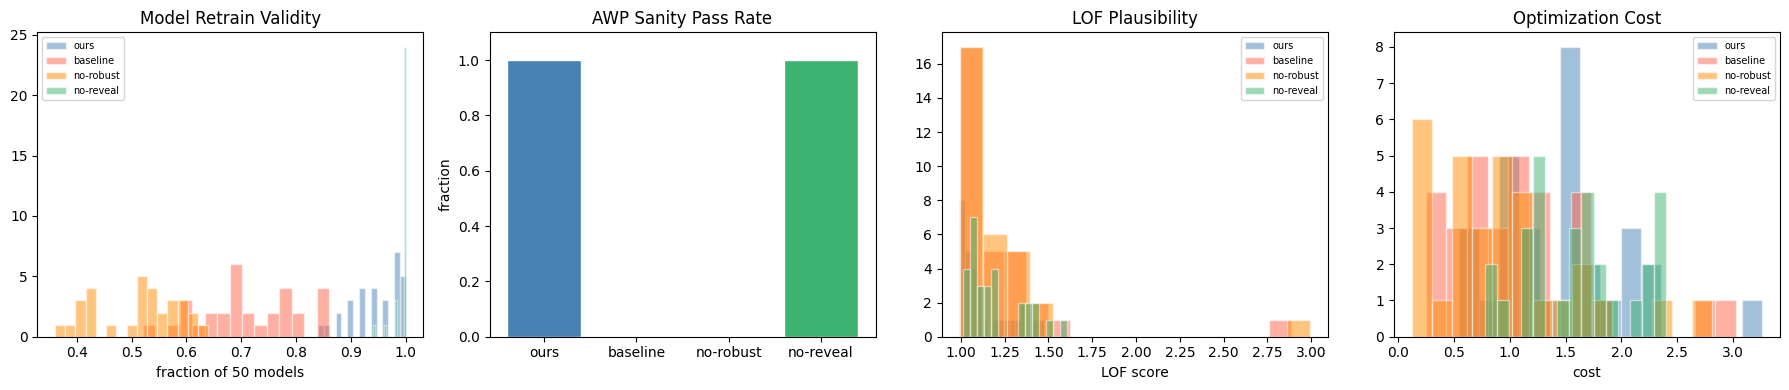

In [18]:
colors_map = {'ours': 'steelblue', 'baseline': 'tomato', 'no-robust': 'darkorange', 'no-reveal': 'mediumseagreen'}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# retrain validity
ax = axes[0]
for label, _, _, _ in conditions:
    feas = [r for r in all_results[label] if r['feasible']]
    if feas:
        ax.hist([r['rr'] for r in feas], bins=15, alpha=0.5, color=colors_map[label], label=label, edgecolor='white')
ax.set_title('Model Retrain Validity')
ax.set_xlabel('fraction of 50 models')
ax.legend(fontsize=7)

# AWP sanity (bar chart)
ax = axes[1]
labels_plot, awp_rates = [], []
for label, _, _, _ in conditions:
    feas = [r for r in all_results[label] if r['feasible']]
    if feas:
        labels_plot.append(label)
        awp_rates.append(np.mean([r['awp'] for r in feas]))
ax.bar(labels_plot, awp_rates, color=[colors_map[l] for l in labels_plot], edgecolor='white')
ax.set_title('AWP Sanity Pass Rate')
ax.set_ylabel('fraction')
ax.set_ylim(0, 1.1)

# LOF
ax = axes[2]
for label, _, _, _ in conditions:
    feas = [r for r in all_results[label] if r['feasible']]
    if feas:
        ax.hist([r['lof'] for r in feas], bins=15, alpha=0.5, color=colors_map[label], label=label, edgecolor='white')
ax.set_title('LOF Plausibility')
ax.set_xlabel('LOF score')
ax.legend(fontsize=7)

# cost
ax = axes[3]
for label, _, _, _ in conditions:
    feas = [r for r in all_results[label] if r['feasible']]
    if feas:
        ax.hist([r['cost'] for r in feas], bins=15, alpha=0.5, color=colors_map[label], label=label, edgecolor='white')
ax.set_title('Optimization Cost')
ax.set_xlabel('cost')
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## Qualitative case studies

In [19]:
for case_num, idx in enumerate(denied_all[:3]):
    x0, xi0 = X[idx], Xi[idx]
    missing_names = [feature_names[j] for j in np.where(xi0 == 1)[0]]
    print(f"\n{'='*80}")
    print(f'Case {case_num+1}  (person {idx})  missing: {missing_names}')
    print(f"{'='*80}")

    r, delta, cost, _, mu, Sigma, draws, rho_opt = beam_search(
        x0, xi0, theta_hat, hessian_matrix, mice_imputer,
        epsilon=EPSILON, rho_coverage=RHO_COVERAGE, kappa=kappa, J_edit=J_edit,
        x_min=x0 - DELTA_MAX, x_max=x0 + DELTA_MAX,
        verbose=False,
    )

    if r is None:
        print('no feasible recourse found')
        continue

    nom = nominal_validity(theta_hat, x0, delta, xi0, r, mu)
    rr  = model_retrain_validity(x0, delta, xi0, r, mu, bootstrap_models)
    awp_s, lb_s = awp_validity(
        theta_hat, hessian_matrix, x0, delta, xi0, r, mu, Sigma,
        epsilon_eval=EPSILON, rho_eval=rho_opt,
    )
    lof = lof_plausibility(x0, delta, xi0, r, mu, lof_model)

    metrics = {
        'total_cost': cost,
        'nominal':    nom,
        'retrain':    rr,
        'awp_sanity': awp_s, 'lb_sanity': lb_s,
        'lof':        lof,
    }
    print_recourse_summary(
        x0, xi0, r, delta, col_means, col_stds, feature_names,
        kappa=kappa, metrics=metrics,
    )


Case 1  (person 336)  missing: ['BloodPressure', 'SkinThickness', 'Insulin']
--------------------------------------------------------------------------------
Feature                       Original  Miss  Reveal  Post-Action      Change
--------------------------------------------------------------------------------
Pregnancies                       0.00    no       -         0.00           -
Glucose                         117.00    no       -       105.16      -11.84
BloodPressure                      ---   yes     yes        73.14    revealed
SkinThickness                      ---   yes       -          ---           -
Insulin                            ---   yes       -          ---           -
BMI                              33.80    no       -        32.10       -1.70
DiabetesPedigreeFunction          0.93    no       -         0.93           -
Age                              44.00    no       -        44.00           -
----------------------------------------------------------